In [ ]:
from flower_model._clustering import _spherical_kmeans
from flower_model.external._gabor_like_filters import _gabor_like_filters
from flower_model._filterbank import _shift_filters
import torch
import matplotlib.pyplot as plt
import math
import numpy as np

In [123]:
N = 27
sigma = 15.
k = 250
steps = 14
SPH_KMEANS_ITERS = 100
device='cuda'

low_freq_upper= 3.
high_freq_lower = 4.
eye_pos = [N/2, N/2]
k_around_eye = 10

In [124]:
filters, r = _gabor_like_filters(N, sigma, 11, 0.7)
print(filters.shape)
print(r.shape)

(397, 27, 27)
(397,)


In [125]:
filters = filters.astype("complex64")
filters = torch.tensor(filters, device=device)
filters = torch.abs(filters)

r = torch.tensor(r, device=device)

In [126]:
filters, filter_pos = _shift_filters(filters, steps, N+1)
shift_dim = filters.size(dim=1)

r = r.repeat((steps*2)**2)

print(filters.shape)
print(filter_pos.shape)
print(r.shape)

torch.Size([311248, 54, 54])
torch.Size([311248, 2])
torch.Size([311248])


In [127]:
filter_amount = filters.size(dim=0)
filters = filters.view(filter_amount, -1)

In [128]:
labels = _spherical_kmeans(k, filters, SPH_KMEANS_ITERS)

In [129]:
centroid_list = []
centroid_r_list = []
centroid_pos_list = []

for cluster in range(k):
    cluster_mask = labels == cluster
    filters_in_cluster = filters[cluster_mask]
    r_in_cluster = r[cluster_mask]
    pos_in_cluster = filter_pos[cluster_mask]

    centroid_list.append(torch.mean(filters_in_cluster, dim=0))
    centroid_r_list.append(torch.mean(r_in_cluster))
    centroid_pos_list.append(torch.mean(pos_in_cluster, dim=0))

centroids = torch.stack(centroid_list)
centroids_r = torch.hstack(centroid_r_list)
centroids_pos = torch.stack(centroid_pos_list)

print(centroids.shape)
print(centroids_r.shape)
print(centroids_pos.shape)

print(centroids_r)

centroids = centroids.view(-1, shift_dim*shift_dim)

torch.Size([250, 2916])
torch.Size([250])
torch.Size([250, 2])
tensor([6.1043, 4.9511, 7.4455, 2.6233, 4.9511, 2.6233, 7.0535, 3.2897, 6.8945,
        7.2257, 3.5839, 7.1406, 7.2198, 5.1511, 4.9543, 6.7642, 4.9511, 6.9973,
        6.8569, 7.0318, 6.9973, 2.7505, 7.3102, 4.9511, 5.1307, 7.3621, 6.5789,
        5.0633, 2.6233, 7.2198, 4.9511, 4.9511, 2.3982, 2.9587, 4.9511, 7.0842,
        2.3636, 6.9973, 5.0394, 3.7820, 4.2525, 5.5135, 2.5507, 4.9511, 4.9511,
        4.9511, 6.9249, 5.2390, 4.6866, 7.3247, 2.7527, 2.3913, 3.9738, 2.3160,
        6.7751, 7.0569, 2.6812, 7.2198, 5.0690, 6.7634, 7.2198, 7.4455, 6.9472,
        5.1302, 4.9906, 4.9511, 6.9973, 5.2389, 2.1748, 4.9511, 5.4564, 6.6877,
        6.9130, 3.9774, 4.9511, 6.7101, 7.0318, 4.7609, 6.9973, 2.7417, 7.2727,
        7.2198, 5.4014, 4.9511, 6.8091, 7.4659, 2.5403, 4.9511, 4.9197, 7.0293,
        2.5800, 7.2198, 5.0030, 4.6188, 4.2646, 4.5283, 6.6688, 2.4968, 2.5599,
        2.7342, 5.0615, 4.2011, 4.9511, 4.9511, 7.1632, 2

tensor([19.0000,  9.5529], device='cuda:0')


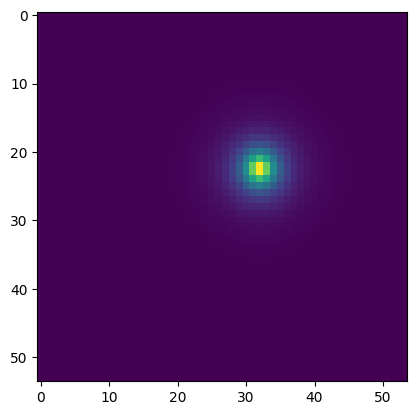

In [130]:
print(centroids_pos[0])
plt.imshow(centroids[0].view(shift_dim, shift_dim).cpu())
plt.show()

In [131]:
low_freq_mask = centroids_r < low_freq_upper
mid_freq_mask = (centroids_r >= low_freq_upper) & (centroids_r <= high_freq_lower)
high_freq_mask = centroids_r > high_freq_lower

low_freq_centroids = centroids[low_freq_mask]
high_freq_centroids = centroids[high_freq_mask]
mid_freq_centroids = centroids[mid_freq_mask]

print(low_freq_centroids.shape)
print(mid_freq_centroids.shape)
print(high_freq_centroids.shape)
print(centroids_r)

torch.Size([44, 2916])
torch.Size([14, 2916])
torch.Size([192, 2916])
tensor([6.1043, 4.9511, 7.4455, 2.6233, 4.9511, 2.6233, 7.0535, 3.2897, 6.8945,
        7.2257, 3.5839, 7.1406, 7.2198, 5.1511, 4.9543, 6.7642, 4.9511, 6.9973,
        6.8569, 7.0318, 6.9973, 2.7505, 7.3102, 4.9511, 5.1307, 7.3621, 6.5789,
        5.0633, 2.6233, 7.2198, 4.9511, 4.9511, 2.3982, 2.9587, 4.9511, 7.0842,
        2.3636, 6.9973, 5.0394, 3.7820, 4.2525, 5.5135, 2.5507, 4.9511, 4.9511,
        4.9511, 6.9249, 5.2390, 4.6866, 7.3247, 2.7527, 2.3913, 3.9738, 2.3160,
        6.7751, 7.0569, 2.6812, 7.2198, 5.0690, 6.7634, 7.2198, 7.4455, 6.9472,
        5.1302, 4.9906, 4.9511, 6.9973, 5.2389, 2.1748, 4.9511, 5.4564, 6.6877,
        6.9130, 3.9774, 4.9511, 6.7101, 7.0318, 4.7609, 6.9973, 2.7417, 7.2727,
        7.2198, 5.4014, 4.9511, 6.8091, 7.4659, 2.5403, 4.9511, 4.9197, 7.0293,
        2.5800, 7.2198, 5.0030, 4.6188, 4.2646, 4.5283, 6.6688, 2.4968, 2.5599,
        2.7342, 5.0615, 4.2011, 4.9511, 4.9511, 7.

In [132]:
eye_pos = torch.tensor(eye_pos, device=device)
pos_diff = centroids_pos - eye_pos
centoroid_distance = torch.linalg.vector_norm(pos_diff, dim=1)

low_freq_distance = centoroid_distance[low_freq_mask]
mid_freq_distance = centoroid_distance[mid_freq_mask]
high_freq_distance = centoroid_distance[high_freq_mask]

low_freq_centroids_eye = low_freq_centroids[low_freq_distance.topk(k_around_eye, largest=False).indices]
mid_freq_centroids_eye = mid_freq_centroids[mid_freq_distance.topk(k_around_eye, largest=False).indices]
high_freq_centroids_eye = high_freq_centroids[high_freq_distance.topk(k_around_eye, largest=False).indices]

print(low_freq_centroids_eye.shape)
print(mid_freq_centroids_eye.shape)
print(high_freq_centroids_eye.shape)

torch.Size([10, 2916])
torch.Size([10, 2916])
torch.Size([10, 2916])


In [133]:
print(low_freq_distance.topk(k_around_eye, largest=False).values)
print(mid_freq_distance.topk(k_around_eye, largest=False).values)
print(high_freq_distance.topk(k_around_eye, largest=False).values)

tensor([1.0122, 2.9332, 3.0931, 3.6267, 4.5731, 4.8215, 4.9881, 5.1384, 5.5337,
        6.0365], device='cuda:0')
tensor([ 4.0619,  5.4269,  6.2112,  6.3817,  6.7452,  8.1616,  8.4425,  9.5455,
        10.7605, 11.3828], device='cuda:0')
tensor([1.0409, 1.3586, 1.4467, 2.1543, 2.1636, 2.3577, 2.9544, 2.9586, 3.0000,
        3.0761], device='cuda:0')


In [134]:
# low_eye_idx = low_freq_distance.topk(k_around_eye, largest=False).indices
# mid_eye_idx = mid_freq_distance.topk(k_around_eye, largest=False).indices
# high_eye_idx = high_freq_distance.topk(k_around_eye, largest=False).indices

# k_array = torch.arange(0, k, device=device)

# low_freq_k = k_array[low_freq_mask]
# high_freq_k = k_array[high_freq_mask]
# mid_freq_k = k_array[mid_freq_mask]

# low_eye = low_freq_k[low_eye_idx]
# mid_eye = mid_freq_k[mid_eye_idx]
# high_eye = high_freq_k[high_eye_idx]

# eye_list = [low_eye, mid_eye, high_eye]
# eye = torch.hstack(eye_list)

# print(low_eye)
# print(mid_eye)
# print(high_eye)

In [135]:
# filters_in_cluster = filters[labels == 1].abs().view(-1, shift_dim*shift_dim)
# print(filters_in_cluster.shape)

# f = filters_in_cluster.squeeze(0).cpu()        # shape [N, 1024]
# print(f.shape)
# n = f.shape[0]
# size = int(math.sqrt(f.shape[1]))
# assert size * size == f.shape[1], "expected square (H*W)"

# cols = int(math.ceil(math.sqrt(n)))
# rows = int(math.ceil(n / cols))

# fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
# axes = np.atleast_1d(axes).flatten()

# for i in range(rows * cols):
#     ax = axes[i]
#     if i < n:
#         img = f[i].reshape(size, size).numpy()
#         ax.imshow(img, cmap="viridis")
#     ax.axis("off")

# plt.tight_layout()
# plt.show()

# centroid = torch.mean(filters_in_cluster, dim=0).view(shift_dim, shift_dim).cpu()
# print(centroid.shape)
# plt.imshow(centroid, cmap='viridis')
# plt.show()

torch.Size([10, 2916])


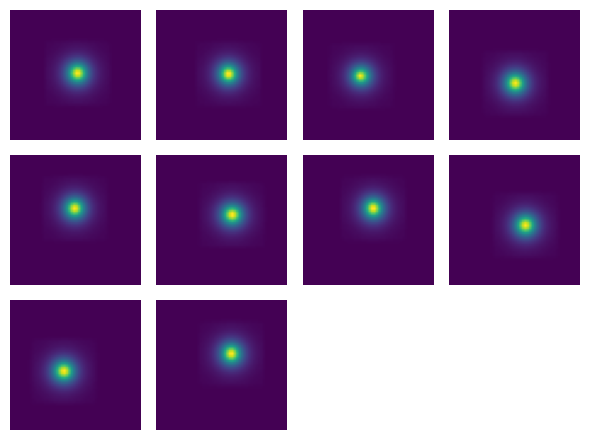

torch.Size([10, 2916])


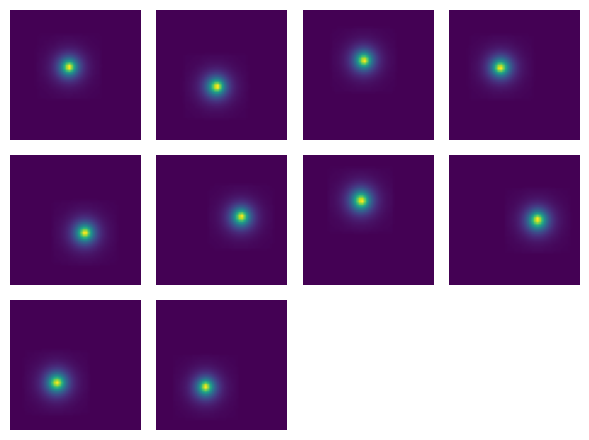

torch.Size([10, 2916])


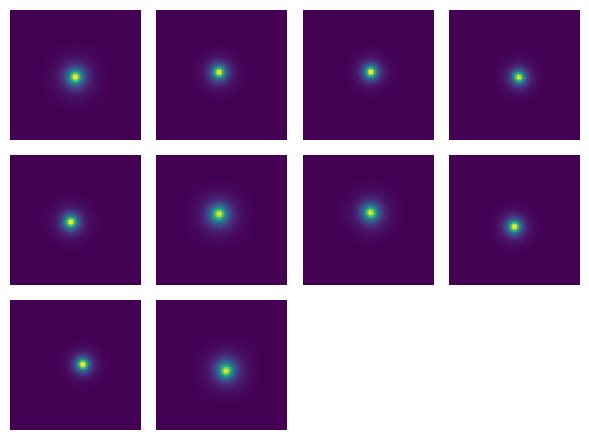

In [136]:
for c in [low_freq_centroids_eye, mid_freq_centroids_eye, high_freq_centroids_eye]:
    f = c.squeeze(0).cpu()
    print(f.shape)
    n = f.shape[0]
    size = int(math.sqrt(f.shape[1]))
    assert size * size == f.shape[1], "expected square (H*W)"

    cols = int(math.ceil(math.sqrt(n)))
    rows = int(math.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols*1.5, rows*1.5))
    axes = np.atleast_1d(axes).flatten()

    for i in range(rows * cols):
        ax = axes[i]
        if i < n:
            img = f[i].reshape(size, size).numpy()
            ax.imshow(img, cmap="viridis")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

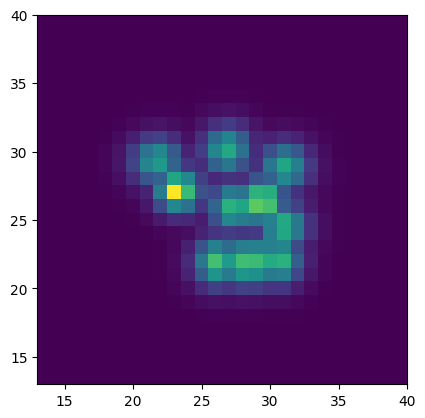

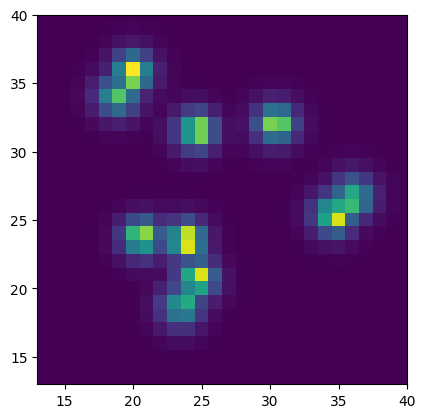

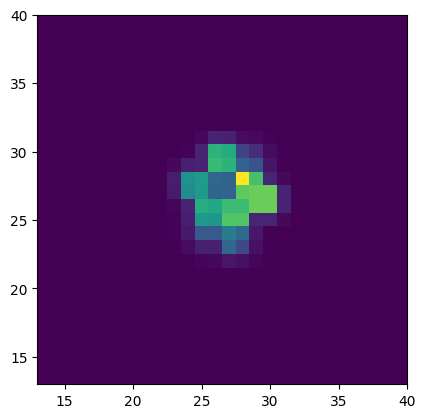

In [137]:
scale = 5
for c in [low_freq_centroids_eye**scale, mid_freq_centroids_eye**scale, high_freq_centroids_eye**scale]:
    f = c.amax(dim=0)
    f = f.view(shift_dim, shift_dim)
    plt.imshow(f.cpu())
    plt.xlim((shift_dim-N)//2, (shift_dim-N)//2 + N)
    plt.ylim((shift_dim-N)//2, (shift_dim-N)//2 + N)
    plt.show()

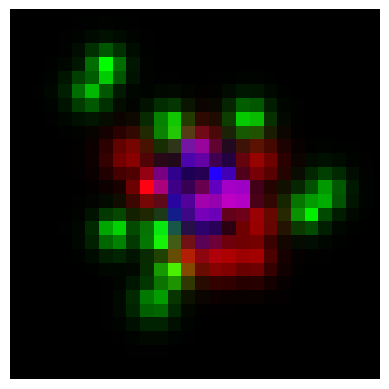

In [138]:
img1 = low_freq_centroids_eye.amax(dim=0).view(shift_dim, shift_dim)**scale
img2 = mid_freq_centroids_eye.amax(dim=0).view(shift_dim, shift_dim)**scale
img3 = high_freq_centroids_eye.amax(dim=0).view(shift_dim, shift_dim)**scale

max = torch.stack([img1, img2, img3]).max()
min = torch.stack([img1, img2, img3]).min()

def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

img1 = normalize(img1)
img2 = normalize(img2)
img3 = normalize(img3)

rgb = torch.stack([img1, img2, img3], dim=-1)

rgb_np = rgb.cpu().numpy()

plt.imshow(rgb_np)
plt.axis("off")
plt.xlim((shift_dim-N)//2, (shift_dim-N)//2 + N)
plt.ylim((shift_dim-N)//2, (shift_dim-N)//2 + N)
plt.show()

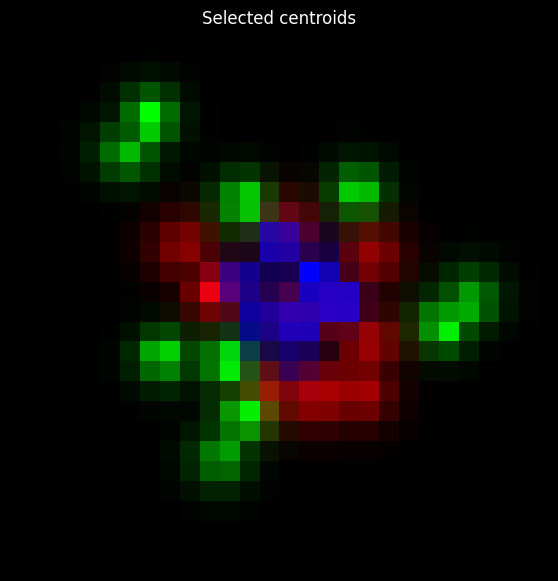

In [139]:
img_low  = (low_freq_centroids_eye**1).amax(dim=0).view(shift_dim, shift_dim)**5
img_mid  = (mid_freq_centroids_eye**1).amax(dim=0).view(shift_dim, shift_dim)**5
img_high = (high_freq_centroids_eye**1).amax(dim=0).view(shift_dim, shift_dim)**5

max = torch.stack([img_low, img_mid, img_high]).max()
min = torch.stack([img_low, img_mid, img_high]).min()

low  = normalize(img_low).cpu().numpy()
mid  = normalize(img_mid).cpu().numpy()
high = normalize(img_high).cpu().numpy()

H, W = low.shape

layer_low = torch.zeros(H, W, 4)
layer_mid = torch.zeros(H, W, 4)
layer_high = torch.zeros(H, W, 4)

layer_low[..., 0] = 1.0
layer_low[..., 3] = torch.tensor(low)

layer_mid[..., 1] = 1.0
layer_mid[..., 3] = torch.tensor(mid)

layer_high[..., 2] = 1.0 
layer_high[..., 3] = torch.tensor(high)

layer_low  = layer_low.numpy()
layer_mid  = layer_mid.numpy()
layer_high = layer_high.numpy()

fig, ax = plt.subplots(figsize=(7, 7), facecolor="black")
ax.set_facecolor("black")

ax.imshow(layer_low)
ax.imshow(layer_mid)
ax.imshow(layer_high)

ax.axis("off")
ax.set_title("Selected centroids", color="white")

ax.set_xlim((shift_dim-N)//2, (shift_dim-N)//2 + N)
ax.set_ylim((shift_dim-N)//2, (shift_dim-N)//2 + N)
plt.show()

In [140]:
low_freq_pos = centroids_pos[low_freq_mask]
mid_freq_pos = centroids_pos[mid_freq_mask]
high_freq_pos = centroids_pos[high_freq_mask]

low_freq_pos_eye = low_freq_pos[low_freq_distance.topk(k_around_eye, largest=False).indices]
mid_freq_pos_eye = mid_freq_pos[mid_freq_distance.topk(k_around_eye, largest=False).indices]
high_freq_pos_eye = high_freq_pos[high_freq_distance.topk(k_around_eye, largest=False).indices]

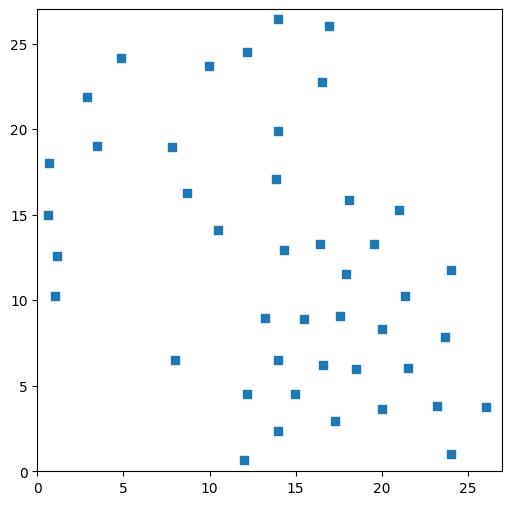

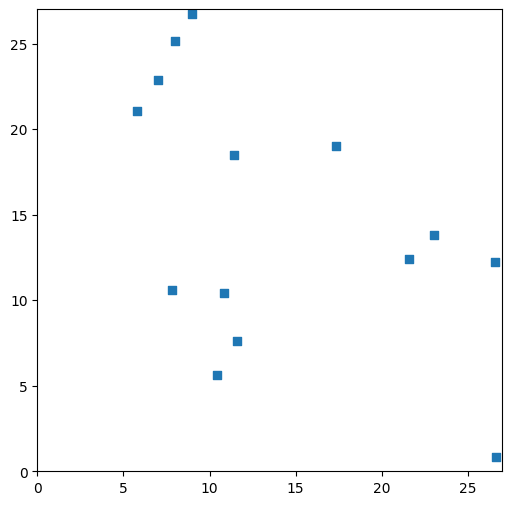

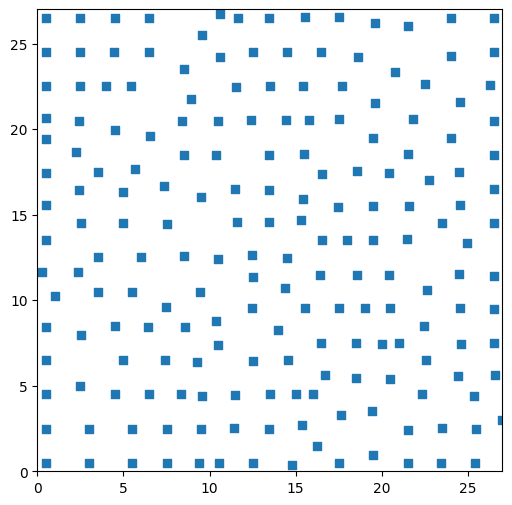

In [141]:
low = low_freq_pos.cpu().numpy()
mid = mid_freq_pos.cpu().numpy()
high = high_freq_pos.cpu().numpy()

for f in [low, mid, high]:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(f[:, 0], f[:, 1], marker="s")
    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    plt.show()

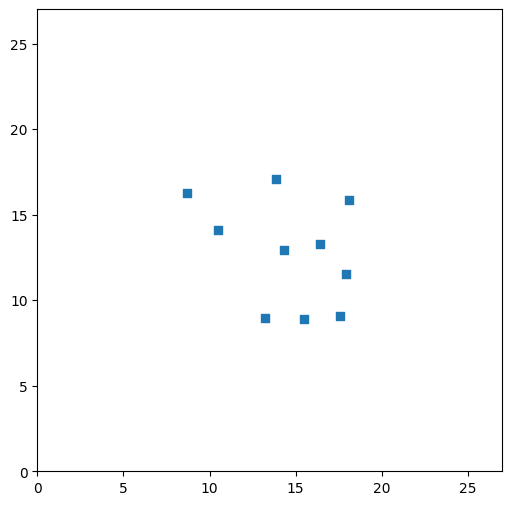

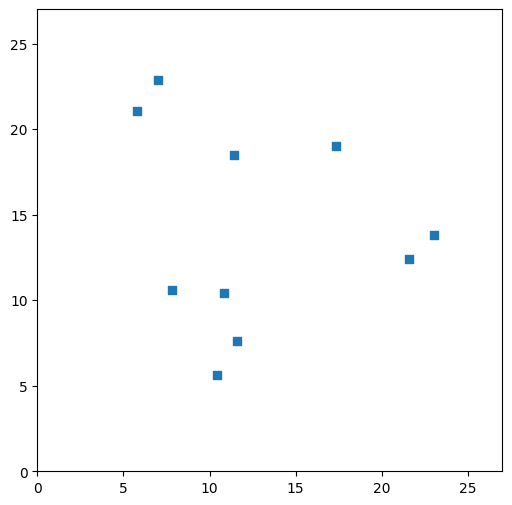

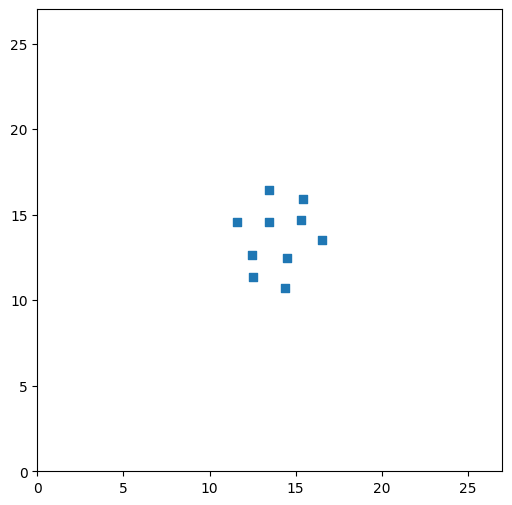

In [142]:
low = low_freq_pos_eye.cpu().numpy()
mid = mid_freq_pos_eye.cpu().numpy()
high = high_freq_pos_eye.cpu().numpy()

for f in [low, mid, high]:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(f[:, 0], f[:, 1], marker="s")
    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    plt.show()

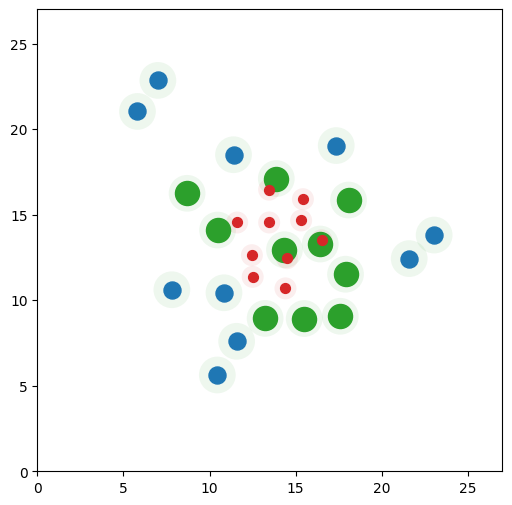

In [143]:
fig, ax = plt.subplots(figsize=(6, 6))

# ax.scatter(low[:, 0],  low[:, 1],  c="tab:green",  marker="s", s=300, label="low")
# ax.scatter(mid[:, 0],  mid[:, 1],  c="tab:blue", marker="s", s=150, label="mid")
# ax.scatter(high[:, 0], high[:, 1], c="tab:red",   marker="s", s=50, label="high")

ax.scatter(low[:,0], low[:,1], s=700, c="tab:green", marker="o", alpha=0.08, edgecolors="none")
ax.scatter(mid[:,0], mid[:,1], s=700, c="tab:green", marker="o", alpha=0.08, edgecolors="none")
ax.scatter(high[:,0], high[:,1], s=250, c="tab:red", marker="o", alpha=0.08, edgecolors="none")

ax.scatter(low[:,0], low[:,1], s=300, c="tab:green", marker="o")
ax.scatter(mid[:, 0],  mid[:, 1],  c="tab:blue", marker="o", s=150, label="mid")
ax.scatter(high[:,0], high[:,1], s=50, c="tab:red", marker="o")

ax.set_xlim(0, N)
ax.set_ylim(0, N)
plt.show()